In [4206]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4207]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms import smallworld
import random
from collections import Counter
from scipy.spatial import cKDTree

from tqdm import tqdm

In [4208]:
from src.neuron_population import NeuronPopulation
from src.connectome import Connectome
from src.overhead import Simulation
from src.neuron_templates import neuron_type_IZ
from src.network_grower import *
from src.network_generators import *
from src.neuron_type_distributor import *
from src.network_weight_distributor import *
from src.external_inputs import *

In [4209]:
weight_scale = 2.0
g = 60

J_I = weight_scale * g
J_E = weight_scale
delay_mean_E = 10.0
delay_std_E = delay_mean_E * 0.5
delay_mean_I = 1.5
delay_std_I = delay_mean_I * 0.2

excitatory_type = "ss4"
inhibitory_type = "b"

In [4210]:
seed = 1234

## Create network

In [ ]:
G = nx.DiGraph()

n_neurons = 4

for i in range(n_neurons):
    G.add_node(i)
    G.nodes[i]['inhibitory'] = False
    G.nodes[i]['ntype'] = excitatory_type
    G.nodes[i]['layer'] = 0

G.nodes[0]["pos"] = np.array([0.0, 0.0])
G.nodes[1]["pos"] = np.array([1.0, 1.0])
G.nodes[2]["pos"] = np.array([1.0, -1.0])
G.nodes[3]["pos"] = np.array([2.0, 0.0])

delay_scale = 5.0 

G.add_edge(0, 1, weight=J_E, distance=np.linalg.norm(G.nodes[0]["pos"] - G.nodes[1]["pos"]) * delay_scale)
G.add_edge(0, 2, weight=J_E, distance=np.linalg.norm(G.nodes[0]["pos"] - G.nodes[2]["pos"]) * delay_scale)

G.add_edge(1, 0, weight=0.1, distance=np.linalg.norm(G.nodes[0]["pos"] - G.nodes[1]["pos"]) * delay_scale)
G.add_edge(2, 0, weight=0.1, distance=np.linalg.norm(G.nodes[0]["pos"] - G.nodes[2]["pos"]) * delay_scale)

G.add_edge(1, 3, weight=0.1, distance=np.linalg.norm(G.nodes[1]["pos"] - G.nodes[3]["pos"]) * delay_scale)

## Inspect network

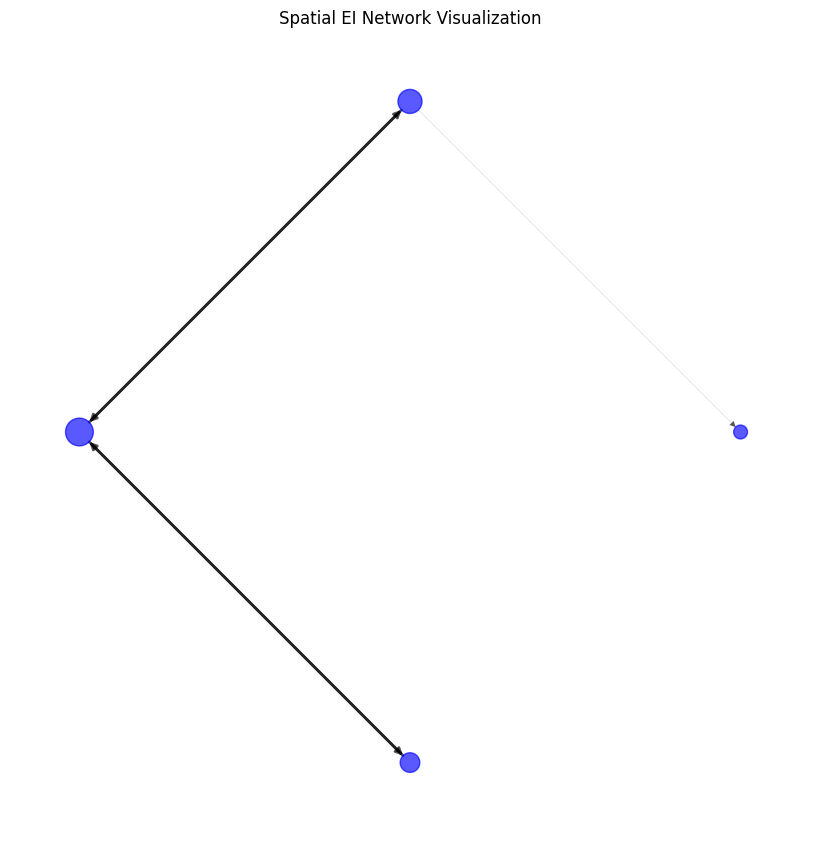

In [4212]:
enable_plot = True

if enable_plot:
    # Plot graph G using "pos" attribute for node positions
    pos = nx.get_node_attributes(G, 'pos')
    # Edge thinckness proportional to weight
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    # Node size proportional to degree
    degrees = [G.degree(n) * 100 for n in G.nodes()]
    # Node color by neuron type
    ntypes = nx.get_node_attributes(G, 'ntype')
    # Map neuron types to colors
    color_map = {'ss4': 'blue', 'b': 'red'}
    node_colors = [color_map.get(ntypes[n], 'gray') for n in G.nodes()]
    # Edge alpha
    alphas = [0.2 + 0.8 * G[u][v]['weight'] / 10.0 for u, v in edges]
    plt.figure(figsize=(8,8))
    nx.draw(G, pos, node_size=degrees, width=weights, edge_cmap=plt.cm.viridis, node_color=node_colors, alpha=0.65, with_labels=False)
    plt.title("Spatial EI Network Visualization")
    plt.show()

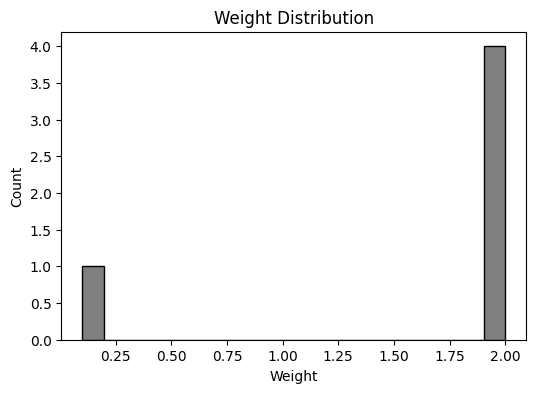

In [4213]:
# Plot weight distribution
weights = [G[u][v]['weight'] for u, v in G.edges()]
plt.figure(figsize=(6,4))
plt.hist(weights, bins=20, color='gray', edgecolor='black')
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.show()

## Simulation Setup

In [4214]:
dt = 0.1

In [4215]:
# Neuron population parameters
n_neurons = G.number_of_nodes()
neuron_types = [excitatory_type, inhibitory_type]
n_neuron_types = len(neuron_types)
inhibitory = [False, True]
threshold_decay = np.exp(-dt / 5)

pop = NeuronPopulation(n_neurons, neuron_types, inhibitory, threshold_decay)

In [4216]:
# Connectome
# Max number of outgoing synapses per neuron
max_synapses = max(dict(G.out_degree()).values())

connectome = Connectome(max_synapses, pop)

connectome.nx_to_connectome(G)

In [4217]:
# connectome.compute_metrics(small_world=False)

In [4218]:
nmda_weight = np.ones(connectome.neuron_population.n_neurons, dtype=float)
nmda_weight[pop.inhibitory_mask.astype(bool)] = 0.959685703507305 * 0.5
# Invert to make excitatory neurons have NMDA weight 1, inhibitory 0
# nmda_weight

### Simulation function

In [4219]:
def sim_w_input(sim, sim_len_ms, input_mask, input_rate, input_amp, plasticity_logger=True):
    poisson = PoissonInput(n_neurons, rate=input_rate * input_mask, amplitude=input_amp)
    steps = int(sim_len_ms / dt)
    post_trace = []
    post_activity_trace = []
    pre_trace = []
    theta = []
    for _ in tqdm(range(steps)):
        if plasticity_logger:
            # post_trace.append(sim.plasticity.post_traces.copy())
            pre_trace.append(sim.plasticity.pre_traces.copy())
            # post_activity_trace.append(sim.plasticity.post_activity_trace.copy())
            # theta.append(sim.plasticity.theta[sim.plasticity.M_sel].copy())
        sim.step(spike_ext=poisson(dt))
    return np.array(post_trace), np.array(pre_trace), np.array(theta), np.array(post_activity_trace)

### Plastic mask

In [4220]:
plastic_mask = np.zeros(n_neurons, dtype=bool)
plastic_mask[:] = True

### Output config

In [4221]:
output_neuron_indices = np.zeros(n_neurons, dtype=bool)
output_neuron_indices[1:] = True
output_neuron_indices

array([False,  True,  True,  True])

### Input config

In [4222]:
input_neuron_indices = np.zeros(n_neurons, dtype=bool)
input_neuron_indices[0] = True
input_neuron_indices

array([ True, False, False, False])

## Simulate

100%|██████████| 10000/10000 [00:01<00:00, 9183.65it/s]


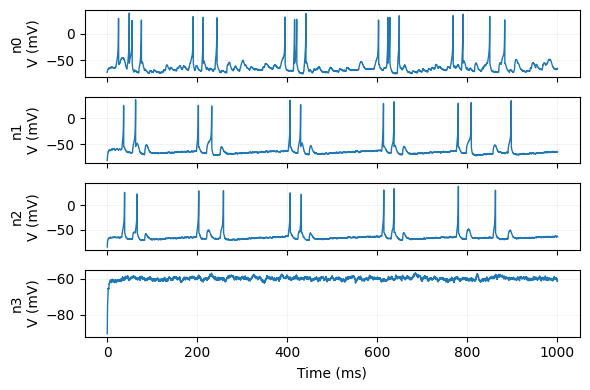

C:\Users\kingt\Dropbox\Programming\NeuralSimV3\NeuroSimV3\python\src\overhead.py:173: RuntimeWarning: invalid value encountered in divide
  fanos = np.where(mu > 0, var / mu, np.nan)


In [4223]:
# Randomize initial voltages
Vs = rng.uniform(-100, -70, size=n_neurons)
us = rng.uniform(0, 400, size=n_neurons)
spikes = np.zeros(n_neurons, dtype=bool)
Ts = np.zeros_like(spikes, dtype=float)

state0 = (Vs,
          us,
          spikes.copy(),
          Ts.copy())

# sim = Simulation(connectome, dt, stepper_type="simple", state0=state0,
#                  enable_plasticity=False)
# sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
#                 synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
#                  enable_debug_logger=False,
#                  enable_plasticity=True, plasticity="dabcm", plasticity_step="pre_post",
#                  plasticity_kwargs={"plastic_source_mask": plastic_mask, "weight_multiplicity": None, 
#                                     "max_weight": 100.0, "weight_update_scale": 1.0})

sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
                synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
                 enable_debug_logger=False,
                 enable_plasticity=True, plasticity="clopath", plasticity_step="pre_post_v",
                 plasticity_kwargs={"plastic_source_mask": plastic_mask, "weight_multiplicity": None, 
                                    "max_weight": 100.0, "weight_update_scale": 1.0,
                                    "enable_debug_logger": True})

# sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
#                 synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
#                  enable_debug_logger=False,
#                  enable_plasticity=True, plasticity="STDP", plasticity_step="pre_post",
#                  plasticity_kwargs={"weight_multiplicity": None, 
#                                     "max_weight": 100.0, "weight_update_scale": 0.1})

sim.configure_output_readout(output_neuron_indices=output_neuron_indices, output_dim=2, rate_window_ms=500.0,
                             enable_logger=True)

# rate = np.zeros(n_neurons)
amplitude = 1 #* 100
v_ext = 100.0

W_old = connectome.W.copy()

# To kickstart SSAI
post, pre, theta, post_a = sim_w_input(sim, sim_len_ms=1000.0, input_mask=input_neuron_indices, 
                               input_rate=v_ext, input_amp=amplitude,
                               plasticity_logger=True)

W_new = connectome.W.copy()

sim.plot_voltage_per_neuron(figsize=(6, 1))

stats = sim.stats.compute_metrics(dt, bin_ms_participation=300)

# isi_mean = stats['ISI_CV_mean']
# isi_top = stats["ISI_CV_mean_top10pct"]

# sim.plot_spike_raster(figsize=(10, 6), title=f"ISI_CV_Mean: {isi_mean:.3f}, ISI_CV_top10pct: {isi_top:.3f}", t_start_ms=0.0, t_stop_ms=9000.0)

# # Plot output
# output_history = np.array(sim.output_logger)
# plt.figure(figsize=(6,4))
# plt.plot(output_history[:, 0], label="Output Neuron 1")
# plt.plot(output_history[:, 1], label="Output Neuron 2")
# plt.title("Output Neuron Firing Rates Over Time")
# plt.xlabel("Time (ms)")
# plt.ylabel("Firing Rate (Hz)")
# plt.legend()
# plt.show()

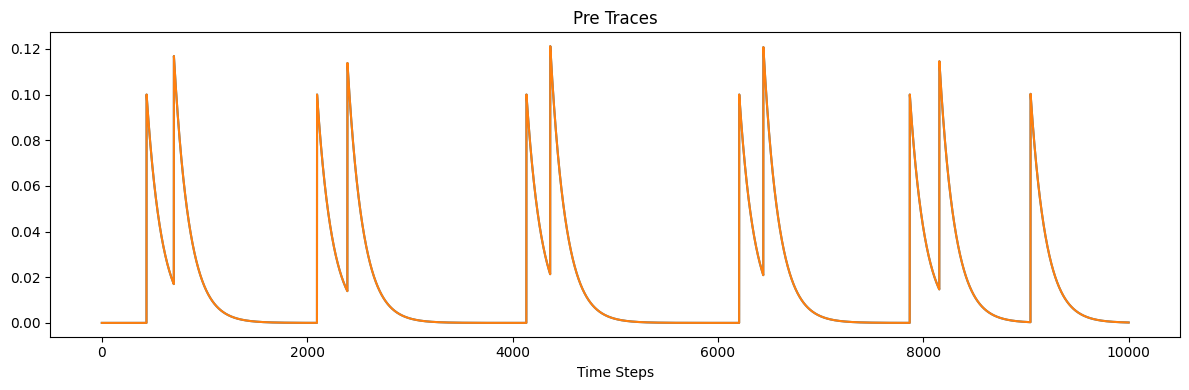

In [4224]:
# Plot pre and post traces and theta

n_test = 1

plt.figure(figsize=(12, 4))
# plt.subplot(1, 3, 1)
# plt.plot(post[:, n_test, :], label=f"Post Trace Neuron {n_test}")
# plt.title("Post Traces")
# plt.xlabel("Time Steps")
# plt.subplot(1, 3, 2)
plt.plot(pre[:, n_test, :], label=f"Pre Trace Neuron {n_test}")
plt.title("Pre Traces")
plt.xlabel("Time Steps")
# plt.subplot(1, 3, 3)
# plt.plot(theta[:, n_test], label=f"Theta Neuron {n_test}")
# plt.title("Theta")
# plt.xlabel("Time Steps")
plt.tight_layout()
plt.show()

In [4225]:
# # Derivative values

# post_drive = post * (post - theta)
# eligibility = pre * post_drive

# # Plot post_drive and eligibility
# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.plot(post_drive[:, n_test, :], label=f"Post Drive Neuron {n_test}")
# plt.title("Post Drive")
# plt.xlabel("Time Steps")
# plt.subplot(1, 2, 2)
# plt.plot(eligibility[:, n_test, :], label=f"Eligibility Neuron {n_test}")
# plt.title("Eligibility")
# plt.xlabel("Time Steps")
# plt.tight_layout()
# plt.show()

In [4226]:
# dw = np.array(sim.plasticity.dws)
# plt.figure(figsize=(6,4))
# plt.plot(dw[:,n_test,:], label=f"Weight Changes")
# plt.title("Weight Changes Over Time")
# plt.xlabel("Time Steps")
# plt.show()

In [4227]:
# eligibility[:, n_test, 0].sum()

In [4228]:
# dw[:, n_test, 0].sum()

In [4229]:
W_old


array([[2. , 2. ],
       [2. , 0.1],
       [2. , 0. ],
       [0. , 0. ]])

In [4230]:
W_new

array([[2.60533384, 2.3826667 ],
       [2.82161185, 0.02470117],
       [3.0002171 , 0.        ],
       [0.        , 0.        ]])

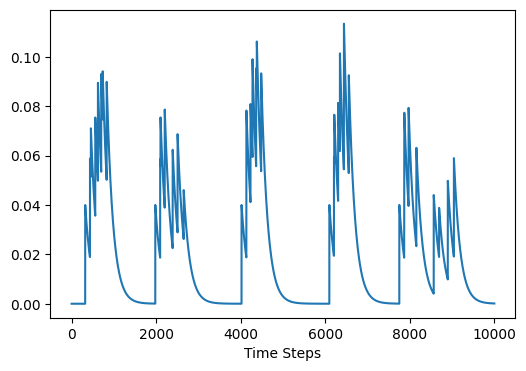

In [4231]:
mean_dw = sim.plasticity.debug_logger["mean_pre_trace"]

# Plot
plt.figure(figsize=(6,4))
plt.plot(mean_dw)
plt.xlabel("Time Steps")
# plt.legend()
plt.show()